In [1]:
import io
import os
import pandas as pd
import gzip as gz
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker
sns.set_theme(font="Arial", font_scale=1.15, style='ticks')
plt.rc("axes.spines", top=False, right=False)

def read_vcf(path):
    with gz.open(path, 'rb') as f:
        lines = [l.decode('utf-8') for l in f if not l.startswith(b'##')]
    return pd.read_csv(
        io.StringIO(''.join(lines)),
        dtype={'#CHROM': str, 'POS': int, 'ID': str, 'REF': str, 'ALT': str,
               'QUAL': str, 'FILTER': str, 'INFO': str},
        sep='\t'
    ).rename(columns={'#CHROM': 'CHROM'})

dir="/mmfs1/gscratch/stergachislab/mhsohny/SMaHT/Improving_SomaticVariantCalling_through_DSA/Fiber-seq/VariantCalls_DeepVariant_1.6.1"

In [50]:
'''
colobl_vcf = read_vcf(f"{dir}/COLO829BL/deepvariant/COLO829BL.deepvariant.vcf.gz")
colotb_vcf = read_vcf(f"{dir}/COLO829T_PassageB_DSA/deepvariant/COLO829T_PassageB_DSA.deepvariant.vcf.gz")
colota_vcf = read_vcf(f"{dir}/COLO829T_PassageA_DSA/deepvariant/COLO829T_PassageA_DSA.deepvariant.vcf.gz")
'''
colobl_vcf = read_vcf(f"{dir}/COLO829BL/deepvariant/COLO829BL.deepvariant.split.snv.modified.vcf.gz")
colotb_vcf = read_vcf(f"{dir}/COLO829T_PassageB_DSA/deepvariant/COLO829T_PassageB_DSA.deepvariant.split.snv.modified.vcf.gz")
colota_vcf = read_vcf(f"{dir}/COLO829T_PassageA_DSA/deepvariant/COLO829T_PassageA_DSA.deepvariant.split.snv.modified.vcf.gz")


## Simple Stats

In [51]:
colobl_vcf

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,FORMAT,COLO829BL
0,haplotype1-0000001,69010,.,G,A,0,RefCall,.,GT:GQ:DP:AD:VAF:PL,"0/0:33:39:22,8:0.205128:0,32,46"
1,haplotype1-0000001,119793,.,T,G,48.2,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:46:190:87,96:0.505263:48,0,51"
2,haplotype1-0000001,1590039,.,T,A,0,RefCall,.,GT:GQ:DP:AD:VAF:PL,"0/0:22:172:122,34:0.197674:0,22,47"
3,haplotype1-0000001,1590040,.,A,T,0,RefCall,.,GT:GQ:DP:AD:VAF:PL,"0/0:43:154:127,22:0.142857:0,43,59"
4,haplotype1-0000001,2005079,.,A,T,0.1,RefCall,.,GT:GQ:DP:AD:VAF:PL,"./.:19:174:113,38:0.218391:0,18,46"
...,...,...,...,...,...,...,...,...,...,...
902920,haplotype2-0000195,23040,.,C,T,11.4,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:11:56:48,8:0.142857:11,0,44"
902921,haplotype2-0000195,23111,.,A,T,1.9,RefCall,.,GT:GQ:DP:AD:VAF:PL,"./.:5:55:47,8:0.145455:0,2,40"
902922,haplotype2-0000195,23141,.,A,G,14.8,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:15:55:47,8:0.145455:14,0,44"
902923,haplotype2-0000195,23237,.,A,G,11.4,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:11:55:47,8:0.145455:11,0,42"


In [48]:
print(f"COLO829BL PASS variants from all tested alleles: {round(colobl_vcf[colobl_vcf['FILTER'] == 'PASS'].index.shape[0]*100 / colobl_vcf.index.shape[0], 2)} %")
print(f"COLO829BL PASS SNVs from all tested SNV alleles: {round(colobl_vcf[(colobl_vcf['FILTER'] == 'PASS') & (colobl_vcf['REF'].str.len() == 1) & (colobl_vcf['ALT'].str.len() == 1)].index.shape[0]*100 / colobl_vcf[((colobl_vcf['REF']).str.len() ==1) & (colobl_vcf['ALT'].str.len()==1)].index.shape[0], 2)} %")

print(f"COLO829T (Passage B) PASS variants from all tested alleles: {round(colotb_vcf[colotb_vcf['FILTER'] == 'PASS'].index.shape[0]*100 / colotb_vcf.index.shape[0], 2)} %")
print(f"COLO829T (Passage B) PASS SNVs from all tested SNV alleles: {round(colotb_vcf[(colotb_vcf['FILTER'] == 'PASS') & (colotb_vcf['REF'].str.len() == 1) & (colotb_vcf['ALT'].str.len() == 1)].index.shape[0]*100 / colotb_vcf[((colotb_vcf['REF']).str.len() ==1) & (colotb_vcf['ALT'].str.len()==1)].index.shape[0], 2)} %")

print(f"COLO829T (Passage A) PASS variants from all tested alleles: {round(colota_vcf[colota_vcf['FILTER'] == 'PASS'].index.shape[0]*100 / colota_vcf.index.shape[0], 2)} %")
print(f"COLO829T (Passage A) PASS SNVs from all tested SNV alleles: {round(colota_vcf[(colota_vcf['FILTER'] == 'PASS') & (colota_vcf['REF'].str.len() == 1) & (colota_vcf['ALT'].str.len() == 1)].index.shape[0]*100 / colota_vcf[((colota_vcf['REF']).str.len() ==1) & (colota_vcf['ALT'].str.len()==1)].index.shape[0], 2)} %")

KeyError: 'FILTER'

In [5]:
colobl_snvs = colobl_vcf[(colobl_vcf['FILTER'] == 'PASS') & (colobl_vcf['REF'].str.len() == 1) & (colobl_vcf['ALT'].str.len() == 1)]
colotb_snvs = colotb_vcf[(colotb_vcf['FILTER'] == 'PASS') & (colotb_vcf['REF'].str.len() == 1) & (colotb_vcf['ALT'].str.len() == 1)]
colota_snvs = colota_vcf[(colota_vcf['FILTER'] == 'PASS') & (colota_vcf['REF'].str.len() == 1) & (colota_vcf['ALT'].str.len() == 1)]

colobl_snvs_refcall = colobl_vcf[(colobl_vcf['FILTER'] == 'RefCall') & (colobl_vcf['REF'].str.len() == 1) & (colobl_vcf['ALT'].str.len() == 1)]
colotb_snvs_refcall = colotb_vcf[(colotb_vcf['FILTER'] == 'RefCall') & (colotb_vcf['REF'].str.len() == 1) & (colotb_vcf['ALT'].str.len() == 1)]
colota_snvs_refcall = colota_vcf[(colota_vcf['FILTER'] == 'RefCall') & (colota_vcf['REF'].str.len() == 1) & (colota_vcf['ALT'].str.len() == 1)]

In [35]:
vafindex = list(set(colobl_snvs['FORMAT'].values))[0].split(':').index('VAF')
dpindex = list(set(colobl_snvs['FORMAT'].values))[0].split(':').index('DP')

{'GT:GQ:DP:AD:VAF:PL'}

Text(0.5, 1.0, 'VAF for RefCall SNVs')

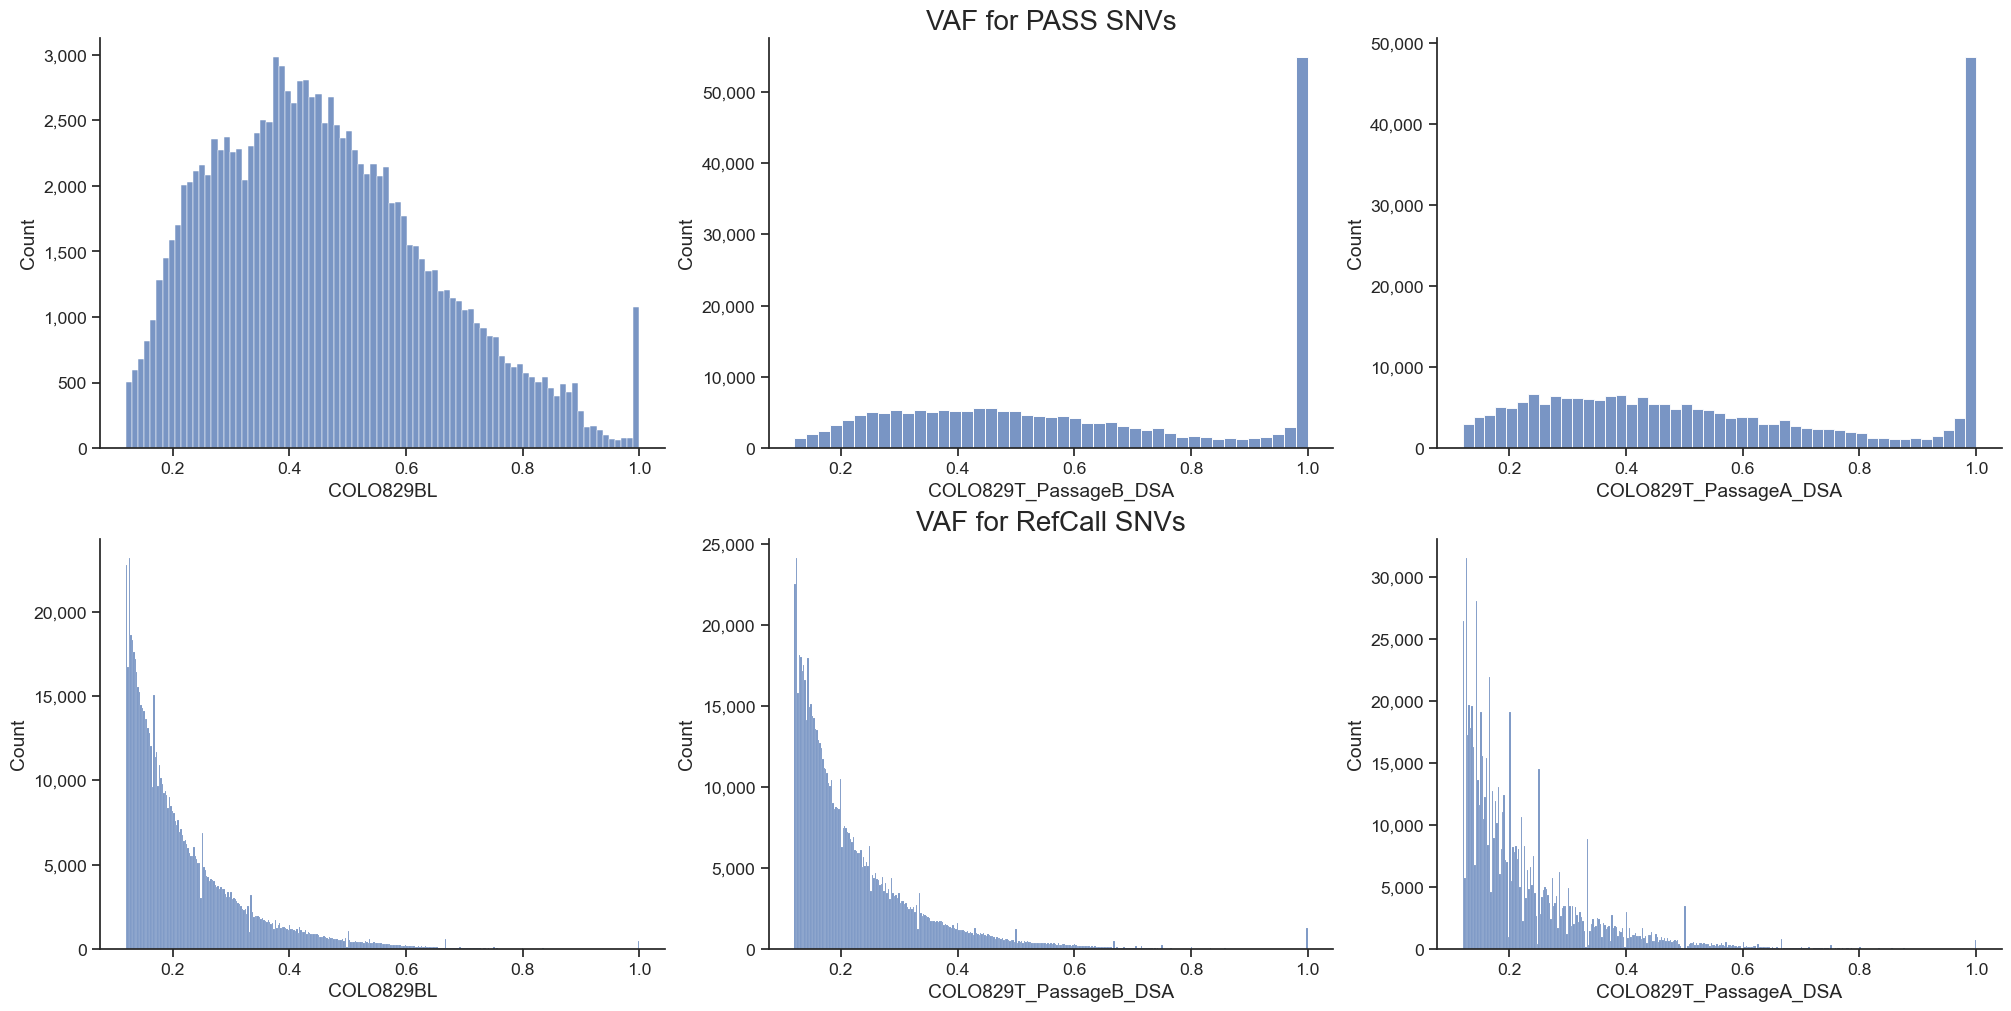

In [7]:
'''
stat
-count: show the number of observations in each bin
-frequency: show the number of observations divided by the bin width
-probability or proportion: normalize such that bar heights sum to 1
-percent: normalize such that bar heights sum to 100
-density: normalize such that the total area of the histogram equals 1
'''
fig, axes = plt.subplots(2,3, figsize=(20,10), constrained_layout=True)
sns.histplot(colobl_snvs['COLO829BL'].str.split(':').apply(lambda x: float(x[vafindex])), ax=axes[0,0])
axes[0,0].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
sns.histplot(colotb_snvs['COLO829T_PassageB_DSA'].str.split(':').apply(lambda x: float(x[vafindex])), ax=axes[0,1])
axes[0,1].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
sns.histplot(colota_snvs['COLO829T_PassageA_DSA'].str.split(':').apply(lambda x: float(x[vafindex])), ax=axes[0,2])
axes[0,2].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

sns.histplot(colobl_snvs_refcall['COLO829BL'].str.split(':').apply(lambda x: float(x[vafindex])), ax=axes[1,0])
axes[1,0].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
sns.histplot(colotb_snvs_refcall['COLO829T_PassageB_DSA'].str.split(':').apply(lambda x: float(x[vafindex])), ax=axes[1,1])
axes[1,1].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
sns.histplot(colota_snvs_refcall['COLO829T_PassageA_DSA'].str.split(':').apply(lambda x: float(x[vafindex])), ax=axes[1,2])
axes[1,2].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

axes[0, 1].set_title('VAF for PASS SNVs', loc='center', fontsize=20)
axes[1, 1].set_title('VAF for RefCall SNVs', loc='center', fontsize=20)

In [8]:
print(f"Minimum VAF for PASS SNVs in COLO829BL: {colobl_snvs['COLO829BL'].str.split(':').apply(lambda x: float(x[vafindex])).min()}")
print(f"Minimum VAF for PASS SNVs  in COLO829T (Passage B): {colotb_snvs['COLO829T_PassageB_DSA'].str.split(':').apply(lambda x: float(x[vafindex])).min()}")
print(f"Minimum VAF for PASS SNVs  in COLO829T (Passage A): {colota_snvs['COLO829T_PassageA_DSA'].str.split(':').apply(lambda x: float(x[vafindex])).min()}")

print(f"Minimum VAF for RefCall SNVs in COLO829BL: {colobl_snvs_refcall['COLO829BL'].str.split(':').apply(lambda x: float(x[vafindex])).min()}")
print(f"Minimum VAF for RefCall SNVs  in COLO829T (Passage B): {colotb_snvs_refcall['COLO829T_PassageB_DSA'].str.split(':').apply(lambda x: float(x[vafindex])).min()}")
print(f"Minimum VAF for RefCall SNVs  in COLO829T (Passage A): {colota_snvs_refcall['COLO829T_PassageA_DSA'].str.split(':').apply(lambda x: float(x[vafindex])).min()}")

Minimum VAF for PASS SNVs in COLO829BL: 0.12
Minimum VAF for PASS SNVs  in COLO829T (Passage B): 0.12
Minimum VAF for PASS SNVs  in COLO829T (Passage A): 0.12
Minimum VAF for RefCall SNVs in COLO829BL: 0.12
Minimum VAF for RefCall SNVs  in COLO829T (Passage B): 0.12
Minimum VAF for RefCall SNVs  in COLO829T (Passage A): 0.12


Text(0.5, 1.0, 'Read Depth for RefCall SNVs')

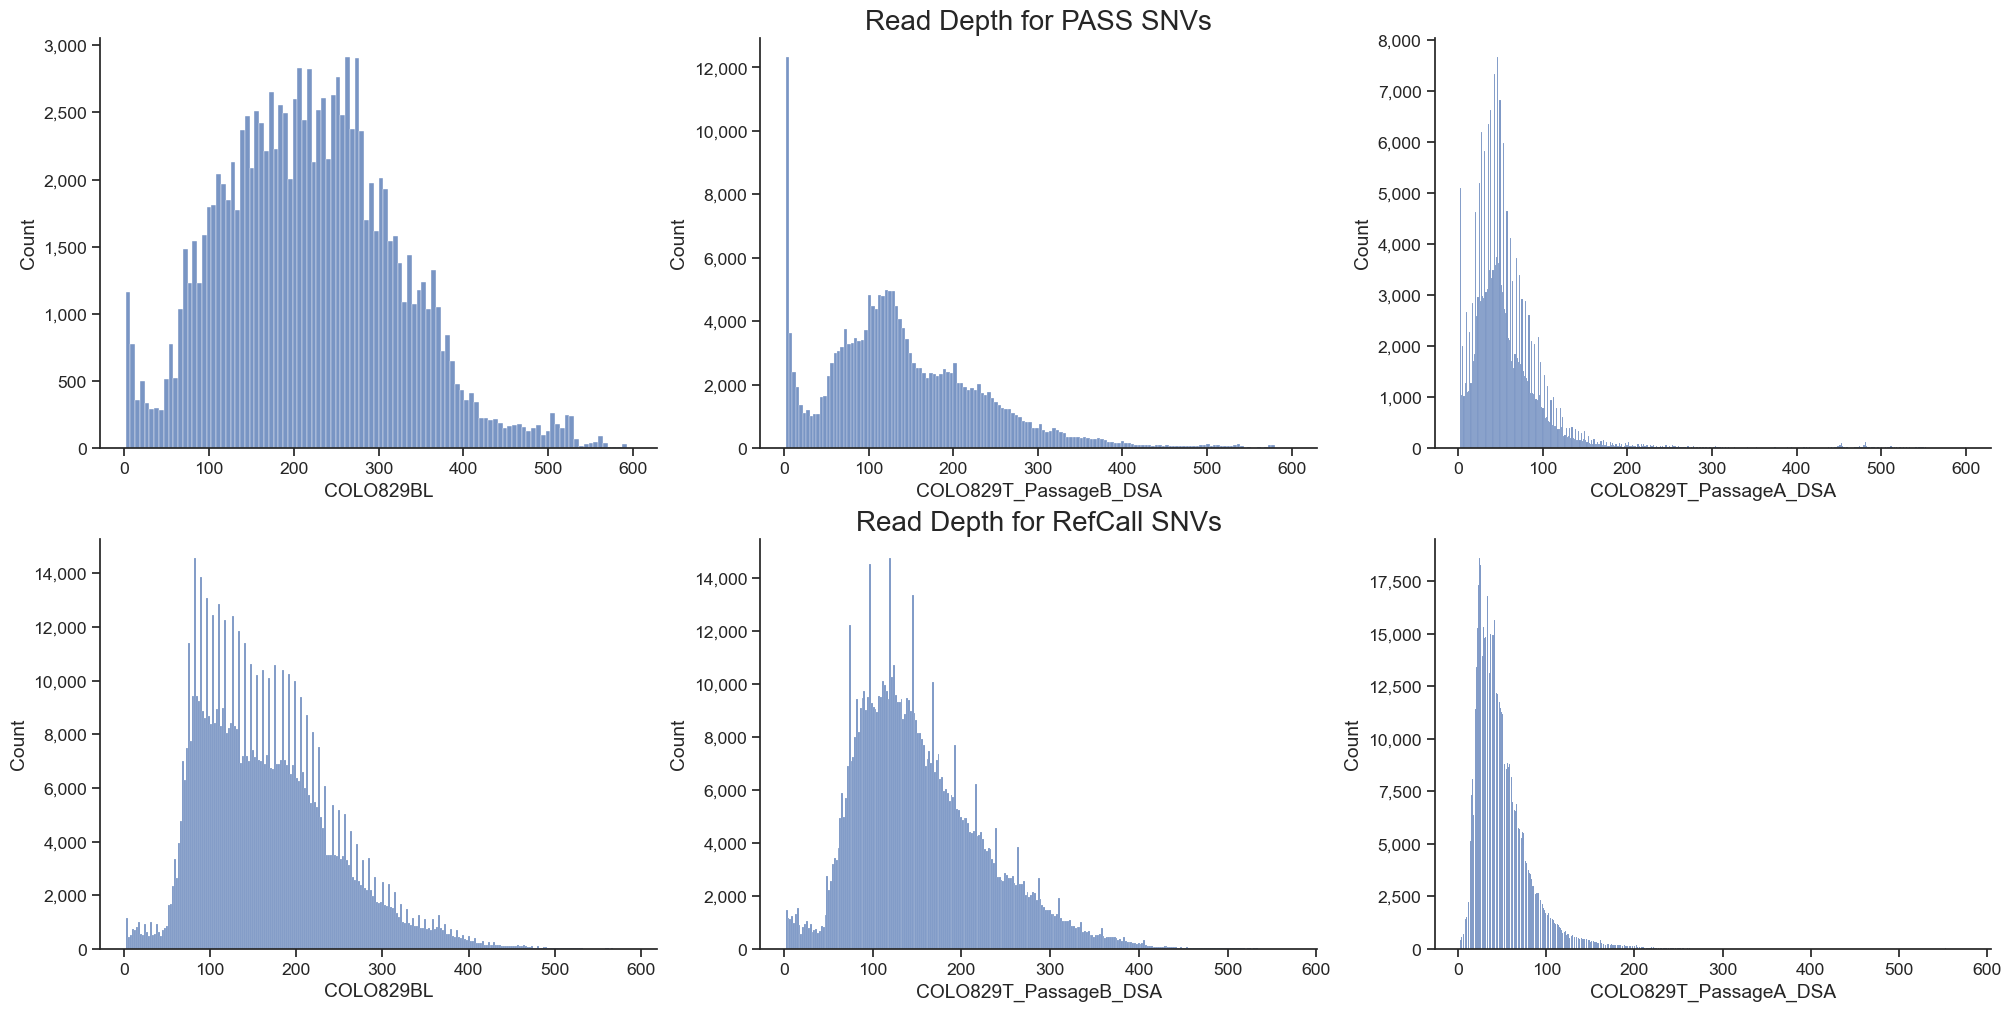

In [9]:
fig, axes = plt.subplots(2,3, figsize=(20,10), constrained_layout=True)
sns.histplot(colobl_snvs['COLO829BL'].str.split(':').apply(lambda x: int(x[dpindex])), ax=axes[0,0])
axes[0,0].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
sns.histplot(colotb_snvs['COLO829T_PassageB_DSA'].str.split(':').apply(lambda x: int(x[dpindex])), ax=axes[0,1])
axes[0,1].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
sns.histplot(colota_snvs['COLO829T_PassageA_DSA'].str.split(':').apply(lambda x: int(x[dpindex])), ax=axes[0,2])
axes[0,2].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

sns.histplot(colobl_snvs_refcall['COLO829BL'].str.split(':').apply(lambda x: int(x[dpindex])), ax=axes[1,0])
axes[1,0].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
sns.histplot(colotb_snvs_refcall['COLO829T_PassageB_DSA'].str.split(':').apply(lambda x: int(x[dpindex])), ax=axes[1,1])
axes[1,1].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
sns.histplot(colota_snvs_refcall['COLO829T_PassageA_DSA'].str.split(':').apply(lambda x: int(x[dpindex])), ax=axes[1,2])
axes[1,2].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

axes[0, 1].set_title('Read Depth for PASS SNVs', loc='center', fontsize=20)
axes[1, 1].set_title('Read Depth for RefCall SNVs', loc='center', fontsize=20)

In [10]:
print(f"Minimum DP for PASS SNVs in COLO829BL: {colobl_snvs['COLO829BL'].str.split(':').apply(lambda x: float(x[dpindex])).min()}")
print(f"Minimum DP for PASS SNVs  in COLO829T (Passage B): {colotb_snvs['COLO829T_PassageB_DSA'].str.split(':').apply(lambda x: float(x[vafindex])).min()}")
print(f"Minimum DP for PASS SNVs  in COLO829T (Passage A): {colota_snvs['COLO829T_PassageA_DSA'].str.split(':').apply(lambda x: float(x[vafindex])).min()}")

print(f"Minimum DP for RefCall SNVs in COLO829BL: {colobl_snvs_refcall['COLO829BL'].str.split(':').apply(lambda x: float(x[vafindex])).min()}")
print(f"Minimum DP for RefCall SNVs  in COLO829T (Passage B): {colotb_snvs_refcall['COLO829T_PassageB_DSA'].str.split(':').apply(lambda x: float(x[vafindex])).min()}")
print(f"Minimum DP for RefCall SNVs  in COLO829T (Passage A): {colota_snvs_refcall['COLO829T_PassageA_DSA'].str.split(':').apply(lambda x: float(x[vafindex])).min()}")

Minimum DP for PASS SNVs in COLO829BL: 2.0
Minimum DP for PASS SNVs  in COLO829T (Passage B): 0.12
Minimum DP for PASS SNVs  in COLO829T (Passage A): 0.12
Minimum DP for RefCall SNVs in COLO829BL: 0.12
Minimum DP for RefCall SNVs  in COLO829T (Passage B): 0.12
Minimum DP for RefCall SNVs  in COLO829T (Passage A): 0.12


In [11]:
test_multi = colobl_vcf[ ((colobl_vcf['FILTER'] == 'PASS')) & (colobl_vcf['REF'].str.len() == 1) & (colobl_vcf['ALT'].apply(lambda x: all(len(alt) == 1 for alt in x.split(',')))) ]
test_multi

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,FORMAT,COLO829BL
34,haplotype1-0000001,119793,.,T,G,48.2,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:46:190:87,96:0.505263:48,0,51"
958,haplotype1-0000001,2005081,.,T,A,8.8,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:9:123:68,55:0.447154:8,0,27"
1606,haplotype1-0000001,3266005,.,G,T,29.8,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:30:175:107,68:0.388571:29,0,52"
2988,haplotype1-0000001,6364498,.,A,G,45.1,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:45:200:105,94:0.47:45,0,57"
3113,haplotype1-0000001,6649941,.,C,T,31.8,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:32:161:92,68:0.42236:31,0,55"
...,...,...,...,...,...,...,...,...,...,...
3790191,haplotype2-0000195,23029,.,C,T,7.4,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:7:56:48,8:0.142857:6,0,42"
3790192,haplotype2-0000195,23040,.,C,T,11.4,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:11:56:48,8:0.142857:11,0,44"
3790194,haplotype2-0000195,23141,.,A,G,14.8,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:15:55:47,8:0.145455:14,0,44"
3790195,haplotype2-0000195,23237,.,A,G,11.4,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:11:55:47,8:0.145455:11,0,42"


In [34]:
colobl_vcf[
    (colobl_vcf['FILTER'] == 'PASS') &
    (colobl_vcf['REF'].str.len() == 1) &
    (colobl_vcf['ALT'].apply(lambda x: any(len(alt) == 1 for alt in x.split(','))))
    ]

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,FORMAT,COLO829BL
34,haplotype1-0000001,119793,.,T,G,48.2,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:46:190:87,96:0.505263:48,0,51"
958,haplotype1-0000001,2005081,.,T,A,8.8,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:9:123:68,55:0.447154:8,0,27"
1606,haplotype1-0000001,3266005,.,G,T,29.8,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:30:175:107,68:0.388571:29,0,52"
2280,haplotype1-0000001,4855815,.,A,"AC,C",30.2,PASS,.,GT:GQ:DP:AD:VAF:PL,"1/2:2:142:49,19,72:0.133803,0.507042:26,13,1,1..."
2988,haplotype1-0000001,6364498,.,A,G,45.1,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:45:200:105,94:0.47:45,0,57"
...,...,...,...,...,...,...,...,...,...,...
3790191,haplotype2-0000195,23029,.,C,T,7.4,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:7:56:48,8:0.142857:6,0,42"
3790192,haplotype2-0000195,23040,.,C,T,11.4,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:11:56:48,8:0.142857:11,0,44"
3790194,haplotype2-0000195,23141,.,A,G,14.8,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:15:55:47,8:0.145455:14,0,44"
3790195,haplotype2-0000195,23237,.,A,G,11.4,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:11:55:47,8:0.145455:11,0,42"


In [12]:
colobl_vcf[
    (colobl_vcf['FILTER'] == 'PASS') &
    (colobl_vcf['REF'].str.len() == 2) &
    (colobl_vcf['ALT'].apply(lambda x: any(len(alt) == 2 for alt in x.split(','))))
    ]

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,FORMAT,COLO829BL
33672,haplotype1-0000001,60494388,.,CG,"C,GG",8.9,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:4:107:47,16,23:0.149533,0.214953:6,0,33,2,..."
923919,haplotype1-0000015,31115637,.,AC,"A,CC",8,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/2:3:126:51,25,46:0.198413,0.365079:1,2,47,0,..."
963905,haplotype1-0000017,11735681,.,GC,"CC,G",12,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:3:95:46,22,14:0.231579,0.147368:8,0,36,0,1..."
974469,haplotype1-0000017,35147334,.,GA,"AA,G",33.1,PASS,.,GT:GQ:DP:AD:VAF:PL,"1/2:3:125:21,31,65:0.248,0.52:29,7,30,13,0,0"
1095105,haplotype1-0000019,54785531,.,CA,"AA,C",11.6,PASS,.,GT:GQ:DP:AD:VAF:PL,"1/2:1:113:19,54,26:0.477876,0.230089:6,0,1,0,0,14"
1106463,haplotype1-0000019,76732902,.,GC,"CC,G",50.4,PASS,.,GT:GQ:DP:AD:VAF:PL,"1/2:3:118:12,40,46:0.338983,0.38983:47,22,28,2..."
1107725,haplotype1-0000019,80060801,.,CT,"C,TT",14.2,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/2:5:191:73,42,72:0.219895,0.376963:12,6,21,0..."
1480275,haplotype1-0000026,109582279,.,GT,"G,TT",33,PASS,.,GT:GQ:DP:AD:VAF:PL,"1/1:3:49:13,24,6:0.489796,0.122449:29,19,0,8,0,31"
2062194,haplotype2-0000053,59150351,.,TA,"AA,T",14.1,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:6:113:2,69,42:0.610619,0.371681:12,0,13,10..."
2398566,haplotype2-0000058,201938956,.,AG,"A,TG",15.1,PASS,.,GT:GQ:DP:AD:VAF:PL,"1/2:3:17:1,8,8:0.470588,0.470588:7,19,6,19,0,1"


In [33]:
print('\t'.join(str(x) for x in colobl_vcf[colobl_vcf['POS'] == 60494388].values[0]))

haplotype1-0000001	60494388	.	CG	C,GG	8.9	PASS	.	GT:GQ:DP:AD:VAF:PL	0/1:4:107:47,16,23:0.149533,0.214953:6,0,33,2,22,29


In [18]:
test_multi = colobl_vcf[ 
                        ((colobl_vcf['FILTER'] == 'PASS')) & 
                        (colobl_vcf['REF'].str.len() == 1) & 
                        (colobl_vcf['ALT'].apply(lambda x: all(len(alt) == 1 for alt in x.split(',')))) 
                        ]

In [19]:
test_multi[test_multi['ALT'].str.contains(',')]

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,FORMAT,COLO829BL
68409,haplotype1-0000001,94816619,.,T,"A,G",51.1,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/2:8:292:109,75,108:0.256849,0.369863:50,6,60..."
223919,haplotype1-0000004,94422395,.,A,"C,G",39.3,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/2:7:40:24,6,10:0.15,0.25:38,5,52,0,52,52"
246340,haplotype1-0000004,135165848,.,G,"A,T",9.7,PASS,.,GT:GQ:DP:AD:VAF:PL,"1/2:3:13:4,6,3:0.461538,0.230769:6,5,3,7,0,8"
388061,haplotype1-0000008,76731048,.,C,"A,G",13.6,PASS,.,GT:GQ:DP:AD:VAF:PL,"1/2:2:6:0,4,2:0.666667,0.333333:9,3,1,4,0,5"
1119837,haplotype1-0000020,3182653,.,G,"A,C",15.3,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:3:312:159,58,91:0.185897,0.291667:12,0,32,..."
...,...,...,...,...,...,...,...,...,...,...
3786942,haplotype2-0000189,43239,.,G,"A,C",17.9,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:5:26:11,11,4:0.423077,0.153846:16,0,23,3,1..."
3787166,haplotype2-0000189,44364,.,G,"C,T",34.4,PASS,.,GT:GQ:DP:AD:VAF:PL,"1/2:22:32:0,12,20:0.375,0.625:34,29,30,29,0,24"
3787263,haplotype2-0000189,44936,.,T,"A,C",19.1,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:3:20:12,5,3:0.25,0.15:16,0,33,0,33,33"
3787399,haplotype2-0000189,45470,.,G,"C,T",5.8,PASS,.,GT:GQ:DP:AD:VAF:PL,"1/2:2:16:7,5,4:0.3125,0.25:0,1,20,2,0,14"


In [31]:
print('\t'.join(str(x) for x in test_multi[test_multi['POS'] == 94816619].values[0]))

haplotype1-0000001	94816619	.	T	A,G	51.1	PASS	.	GT:GQ:DP:AD:VAF:PL	0/2:8:292:109,75,108:0.256849,0.369863:50,6,60,0,60,60


## Difference btw Passage B and Passage A

In [16]:
colobl_snvs

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,FORMAT,COLO829BL
34,haplotype1-0000001,119793,.,T,G,48.2,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:46:190:87,96:0.505263:48,0,51"
958,haplotype1-0000001,2005081,.,T,A,8.8,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:9:123:68,55:0.447154:8,0,27"
1606,haplotype1-0000001,3266005,.,G,T,29.8,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:30:175:107,68:0.388571:29,0,52"
2988,haplotype1-0000001,6364498,.,A,G,45.1,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:45:200:105,94:0.47:45,0,57"
3113,haplotype1-0000001,6649941,.,C,T,31.8,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:32:161:92,68:0.42236:31,0,55"
...,...,...,...,...,...,...,...,...,...,...
3790191,haplotype2-0000195,23029,.,C,T,7.4,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:7:56:48,8:0.142857:6,0,42"
3790192,haplotype2-0000195,23040,.,C,T,11.4,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:11:56:48,8:0.142857:11,0,44"
3790194,haplotype2-0000195,23141,.,A,G,14.8,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:15:55:47,8:0.145455:14,0,44"
3790195,haplotype2-0000195,23237,.,A,G,11.4,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:11:55:47,8:0.145455:11,0,42"


In [17]:
print('asdf')

asdf
